# 04 · Access and connectivity

Sources: OpenStreetMap India via Geofabrik (ODbL) · MoRTH Annual Report 2024-25, Appendix-2 (as on 31.12.2024) · WorldPop 2020 1 km (CC BY 4.0) · GHSL built-up (CC BY 4.0) · MoRTH Road Accidents in India 2024 · NHAI Datalake — aggregates only (ADR-0014). Rebuild everything: `cd ml && uv run python -m fields.national_highways all`.

Distance is straight-line from each populated 1 km pixel to the nearest operational NH or expressway (v2: road-network distance). 'With pipeline' adds OSM construction/proposed ways and NHAI stretches with a target FY — what the pipeline changes, not a forecast.

In [1]:
import json
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

ML = Path.cwd().resolve().parents[1]  # ml/notebooks/national_highways -> ml
sys.path.insert(0, str(ML))
from fields.national_highways import analysis as nh

A = nh.A
SUMMARY = json.loads((A / "summary.json").read_text())
pd.set_option("display.max_rows", 40)
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.dpi": 80, "figure.figsize": (9, 4.5), "axes.spines.top": False, "axes.spines.right": False})

In [2]:
acc = pd.read_csv(A / "access_by_state.csv", index_col=0)
i = acc.loc["India"]
print(f"People: {i.population / 1e7:,.1f} crore. Within 5 / 10 / 25 km today: "
      f"{i.share_within_5km_now:.1%} / {i.share_within_10km_now:.1%} / {i.share_within_25km_now:.1%}. "
      f"Within 10 km with the pipeline: {i.share_within_10km_future:.1%}. "
      f"Beyond 25 km today: {i.people_beyond_25km_now / 1e6:,.1f} million; "
      f"gaining 10-km access from the pipeline: {i.people_gaining_10km / 1e6:,.1f} million.")

People: 138.0 crore. Within 5 / 10 / 25 km today: 58.9% / 79.0% / 97.3%. Within 10 km with the pipeline: 80.6%. Beyond 25 km today: 36.8 million; gaining 10-km access from the pipeline: 21.4 million.


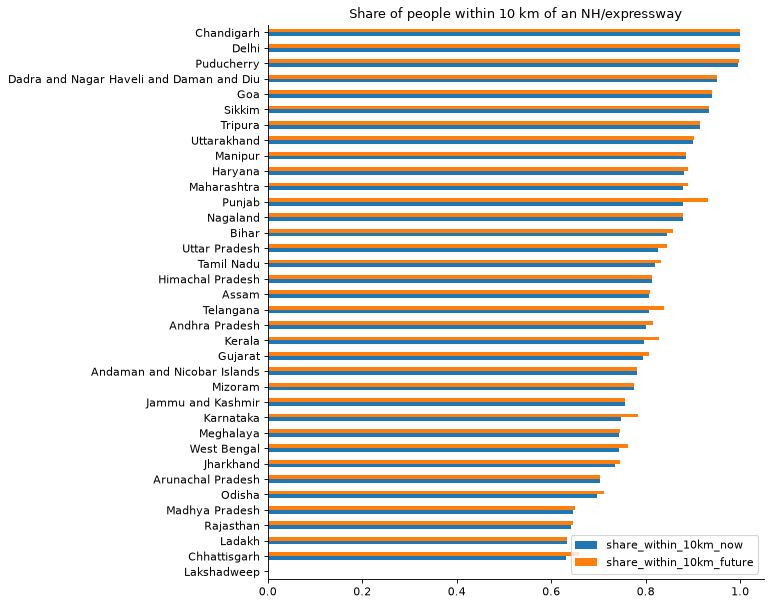

In [3]:
s = acc.drop("India").sort_values("share_within_10km_now")
ax = s.plot.barh(y=["share_within_10km_now", "share_within_10km_future"], figsize=(8, 9), title="Share of people within 10 km of an NH/expressway")
ax.set_ylabel("");

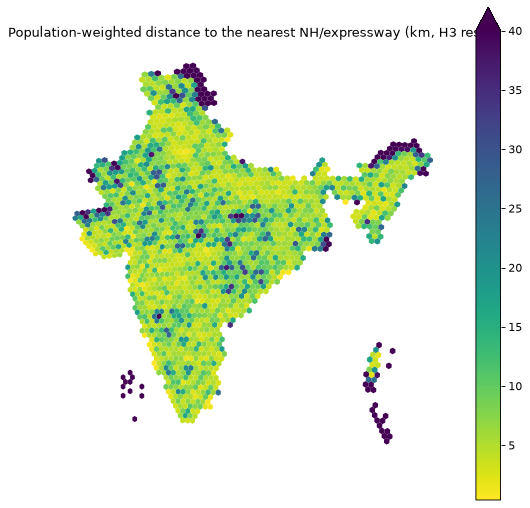

In [4]:
hexes = gpd.read_file(nh.FIXTURES / "nh_access.geojson")
ax = hexes.plot(column="nh_distance_km", cmap="viridis_r", legend=True, figsize=(8, 8), vmax=40)
ax.set_axis_off(); ax.set_title("Population-weighted distance to the nearest NH/expressway (km, H3 res 4)");

## Density

In [5]:
den = pd.read_csv(A / "density_by_state.csv", index_col=0)
den[["official_km", "km_per_1000_km2", "km_per_lakh_people"]].round(1)

,official_km,km_per_1000_km2,km_per_lakh_people
state,,,
Delhi,157,105.70,0.80
Chandigarh,15,130.90,1.70
West Bengal,3910,45.90,3.90
Puducherry,64,127.60,4.60
Bihar,6132,65.10,4.90
Uttar Pradesh,12123,50.30,5.20
Kerala,1858,47.90,5.50
Dadra and Nagar Haveli and Daman and Diu,59,100.50,7.20
Tamil Nadu,7000,53.80,8.70


## City-pair circuity
Network km ÷ straight-line km for large-city pairs 100–600 km apart, on the NH graph only. Above the flag (1.5) = candidate missing link; `pipeline_on_route` = pipeline work within 10 km of the straight line.

In [6]:
pairs = pd.read_csv(A / "city_pairs.csv")
flag = nh.CFG["circuity_flag"]
print(f"{len(pairs):,} pairs; median circuity {pairs.circuity.median():.2f}; above {flag}: {(pairs.circuity > flag).sum():,} "
      f"(of which pipeline on route: {pairs[pairs.circuity > flag].pipeline_on_route.mean():.0%}); unreachable: {pairs.network_km.isna().sum():,}")
pairs.dropna().head(20).round(2)

1,543 pairs; median circuity 1.18; above 1.5: 70 (of which pipeline on route: 93%); unreachable: 0


,city_a,city_b,straight_km,network_km,circuity,pipeline_on_route
0,Bhavnagar,Bilimora,138.30,376.96,2.73,False
1,Virar,Bhavnagar,264.46,548.99,2.08,True
2,Nashik,Bhavnagar,259.32,534.00,2.06,True
3,Bhayandar,Bhavnagar,282.04,569.69,2.02,True
4,Dombivali,Bhavnagar,298.12,591.65,1.98,True
5,Borivli,Bhavnagar,289.40,570.19,1.97,True
6,Bhiwandi,Bhavnagar,288.53,566.35,1.96,True
7,Thane,Bhavnagar,296.37,579.41,1.96,True
8,Kalyan,Bhavnagar,297.12,580.17,1.95,True
9,Bhavnagar,Ulhasnagar,300.45,581.48,1.94,True
